# 17 - SHAP Model Interpretation

## Objectives

- Use SHAP (SHapley Additive exPlanations) to interpret model predictions globally and locally
- Understand which features drive GLOF risk predictions
- Validate thresholds found in Notebook 16 using SHAP values
- Generate publication-quality interpretation figures

**Input**: `models/best_model.joblib`, `data/processed/labeled/training_data.csv`
**Output**: `data/processed/shap_feature_importance.csv`, `figures/shap_*.png`

In [1]:
# --- GLOF PROJECT STANDARD SETUP ---
import os
import sys
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
try:
    import geopandas as gpd
except ImportError:
    pass

project_root = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(project_root))

import importlib
import src.gpu_utils
importlib.reload(src.gpu_utils)

# Fix PROJ: usar proj.db de rasterio (v1.6) en vez del de pyproj (v1.4)
if 'PROJ_LIB' in os.environ:
    del os.environ['PROJ_LIB']
try:
    import rasterio as _rio
    _proj_data = Path(_rio.__file__).parent / 'proj_data'
    if _proj_data.exists():
        os.environ['PROJ_LIB'] = str(_proj_data)
    del _rio, _proj_data
except Exception:
    pass

from src.gpu_utils import GPUConfig, gpu_array, cpu_array
gpu_config = GPUConfig()
print(gpu_config)

GPU_AVAILABLE = gpu_config.has_gpu
CUPY_AVAILABLE = gpu_config.cupy_available

GPU CONFIGURATION
GPU Available: True
Device: NVIDIA GeForce RTX 3050 Laptop GPU
Device Count: 1
Memory Total: 4.0 GB
Memory Free: 2.9 GB
CUDA Version: 595.58.03

Library Support:
  - CuPy:         yes
  - PyTorch CUDA: no
  - Numba CUDA:   yes


In [2]:
# Imports specific to this notebook
import json
import joblib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

try:
    import shap
    SHAP_AVAILABLE = True
    print(f'SHAP version: {shap.__version__}')
except ImportError:
    SHAP_AVAILABLE = False
    print('WARNING: shap not installed. Run: pip install shap')

print(f'SHAP available: {SHAP_AVAILABLE}')

SHAP version: 0.49.1
SHAP available: True


In [3]:
# =============================================================================
# CONFIGURATION
# =============================================================================
DATA_DIR = project_root / 'data'
PROCESSED_DIR = DATA_DIR / 'processed'
MODELS_DIR = project_root / 'models'
FIG_DIR = project_root / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 12,
})

NON_FEATURE_COLS = [
    'had_glof', 'lake_id', 'geometry', 'index',
    'glof_date', 'source', 'fid', 'id', 'name',
]

print(f'Project root : {project_root}')
print(f'Figures dir  : {FIG_DIR}')

Project root : /home/andre/Documents/GLOF_Andes_Project-Paper
Figures dir  : /home/andre/Documents/GLOF_Andes_Project-Paper/figures


## 1. Load Model and Data

In [4]:
# Load best model
model = None
model_path = MODELS_DIR / 'best_model.joblib'

if model_path.exists():
    model = joblib.load(model_path)
    print(f'Loaded model : {type(model).__name__}')
    if hasattr(model, 'n_estimators'):
        print(f'  n_estimators: {model.n_estimators}')
    if hasattr(model, 'feature_importances_'):
        print(f'  Has feature_importances_: True')
else:
    print(f'WARNING: Model not found at {model_path}')
    print('         Run notebook 15_model_training.ipynb first.')

Loaded model : BalancedRandomForestClassifier
  n_estimators: 500
  Has feature_importances_: True


In [5]:

# Load training data, aplicar MISMO feature engineering que NB15
X = None
y = None
df = None

train_path         = PROCESSED_DIR / 'labeled' / 'training_data.csv'
feature_names_path = MODELS_DIR / 'feature_names.json'

if train_path.exists():
    df = pd.read_csv(train_path)
    print(f'Loaded data  : {df.shape[0]} rows x {df.shape[1]} cols')

    # ── Ingeniería de features IDÉNTICA a NB15 cell-4 ──────────────────
    exclude_cols = [
        'lake_id', 'glof_label', 'country', 'cordillera',
        'geometry', 'year', 'source', 'area_name', 'scene_date',
        'glof_volume_m3', 'glof_match_dist_m',
        'glof_date', 'glof_trigger', 'glof_lake_name',
    ]
    base_cols = [c for c in df.columns
                 if c not in exclude_cols
                 and df[c].dtype in ['float64', 'float32', 'int64', 'int32']]
    X_raw = df[base_cols].copy()
    X_raw = X_raw.fillna(X_raw.median(numeric_only=True)).fillna(0)

    log_cols = [c for c in ['area_m2', 'perimeter_m', 'volume_m3', 'equivalent_diameter_m',
                             'potential_energy', 'depth_m', 'dam_height',
                             'area_2017_est', 'area_2025_est', 'total_growth_m2']
                if c in X_raw.columns]
    for c in log_cols:
        X_raw[f'log_{c}'] = np.log1p(X_raw[c].clip(lower=0))

    if 'total_growth_m2' in X_raw.columns and 'area_2017_est' in X_raw.columns:
        X_raw['rel_growth'] = X_raw['total_growth_m2'] / (X_raw['area_2017_est'] + 1)
    if 'slope_mean' in X_raw.columns and 'log_area_m2' in X_raw.columns:
        X_raw['slope_x_logarea'] = X_raw['slope_mean'] * X_raw['log_area_m2']
    if 'dist_glacier_m' in df.columns:
        X_raw['no_glacier'] = (df['dist_glacier_m'].isna()).astype(int)

    # ── Filtrar a feature_cols exactas de NB15 ─────────────────────────
    if feature_names_path.exists():
        with open(feature_names_path) as f:
            feature_cols = json.load(f)
        missing = [c for c in feature_cols if c not in X_raw.columns]
        if missing:
            print(f'WARNING: {len(missing)} features no encontradas: {missing[:5]}')
        feature_cols = [c for c in feature_cols if c in X_raw.columns]
        X = X_raw[feature_cols].copy()
        print(f'Features (desde feature_names.json): {len(feature_cols)}')
    else:
        X = X_raw.copy()
        feature_cols = list(X.columns)
        print(f'WARNING: feature_names.json no encontrado — usando {len(feature_cols)} features')

    # Target
    if 'glof_label' in df.columns:
        y = df['glof_label'].astype(int).values
    elif 'had_glof' in df.columns:
        y = df['had_glof'].astype(int).values
    else:
        y = np.zeros(len(df), dtype=int)

    print(f'Feature matrix : {X.shape}')
    print(f'GLOFs          : {int(y.sum())} / {len(y)}')
else:
    print(f'WARNING: Training data no encontrado en {train_path}')


Loaded data  : 12588 rows x 56 cols
Features (desde feature_names.json): 58
Feature matrix : (12588, 58)
GLOFs          : 16 / 12588


## 2. Create SHAP Explainer

In [6]:

# Crear SHAP TreeExplainer y extraer valores para la clase positiva
shap_values = None
explainer = None
expected_value = None

if not SHAP_AVAILABLE:
    print('ERROR: shap no instalado.')
elif model is None:
    print('WARNING: Modelo no cargado — ejecutar NB15 primero.')
elif X is None:
    print('WARNING: Datos no cargados.')
else:
    model_type = type(model).__name__
    print(f'Modelo: {model_type}')
    tree_kws = ('XGB', 'Forest', 'Boost', 'Tree', 'Gradient', 'Balanced')
    is_tree  = any(kw in model_type for kw in tree_kws)

    try:
        if is_tree:
            print('Usando TreeExplainer (exacto para árboles)...')
            explainer  = shap.TreeExplainer(model)
            sv_raw     = explainer.shap_values(X)
            ev_raw     = explainer.expected_value

            # SHAP ≥0.46 devuelve ndarray 3D (n_samples, n_features, n_classes)
            # SHAP antiguo devuelve lista [neg_class, pos_class]
            if isinstance(sv_raw, np.ndarray) and sv_raw.ndim == 3:
                shap_values    = sv_raw[:, :, 1]           # clase positiva
                expected_value = float(ev_raw[1]) if hasattr(ev_raw, '__len__') else float(ev_raw)
            elif isinstance(sv_raw, list):
                shap_values    = sv_raw[1]
                expected_value = float(ev_raw[1]) if hasattr(ev_raw, '__len__') else float(ev_raw)
            else:
                shap_values    = sv_raw
                expected_value = float(ev_raw[1]) if hasattr(ev_raw, '__len__') else float(ev_raw)
        else:
            print('Usando KernelExplainer (lento, agnóstico al modelo)...')
            background = shap.sample(X, min(100, len(X)))
            explainer  = shap.KernelExplainer(model.predict_proba, background)
            sv_raw     = explainer.shap_values(X)
            if isinstance(sv_raw, np.ndarray) and sv_raw.ndim == 3:
                shap_values = sv_raw[:, :, 1]
            elif isinstance(sv_raw, list):
                shap_values = sv_raw[1]
            else:
                shap_values = sv_raw
            ev_raw = explainer.expected_value
            expected_value = float(ev_raw[1]) if hasattr(ev_raw, '__len__') else float(ev_raw)

        print(f'SHAP values shape  : {shap_values.shape}  ← debe ser (n_samples, n_features)')
        print(f'Expected value     : {expected_value:.4f}')

    except Exception as e:
        print(f'ERROR en SHAP explainer: {e}')
        import traceback; traceback.print_exc()


Modelo: BalancedRandomForestClassifier
Usando TreeExplainer (exacto para árboles)...
SHAP values shape  : (12588, 58)  ← debe ser (n_samples, n_features)
Expected value     : 0.5000


## 3. Global Feature Importance (Bar Plot)

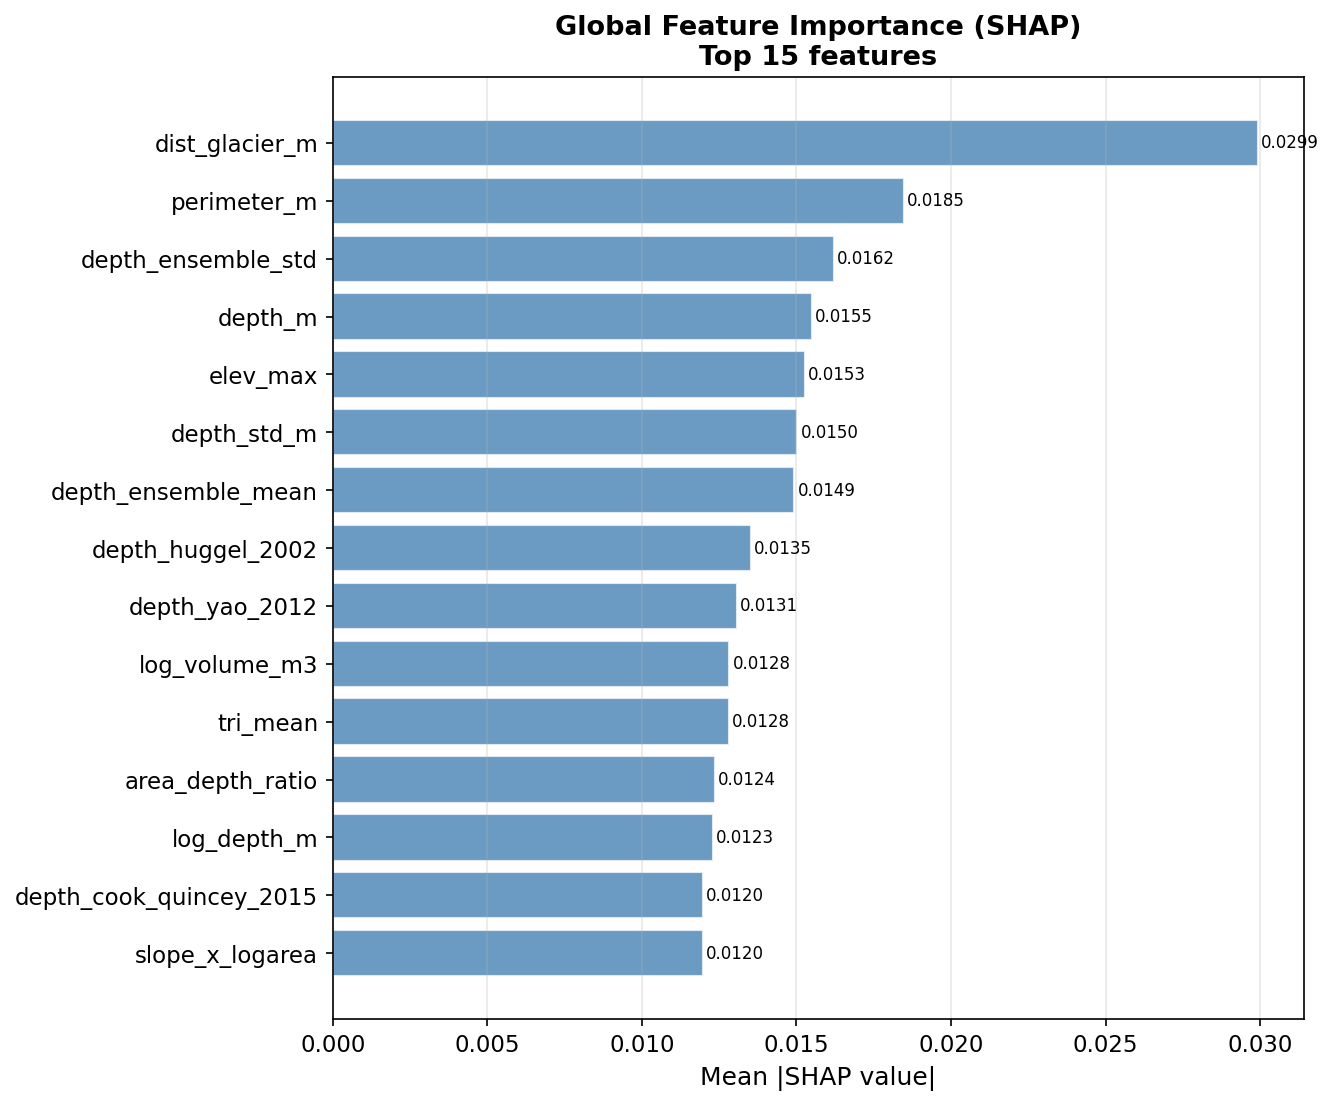

Saved: shap_importance_bar.png

Top 10 features by SHAP importance:
            feature  mean_abs_shap
     dist_glacier_m       0.029925
        perimeter_m       0.018471
 depth_ensemble_std       0.016205
            depth_m       0.015505
           elev_max       0.015275
        depth_std_m       0.015030
depth_ensemble_mean       0.014934
  depth_huggel_2002       0.013524
     depth_yao_2012       0.013061
      log_volume_m3       0.012831


In [ ]:

# SHAP global feature importance bar plot
importance_df = None
mean_abs_shap = None

if shap_values is not None and X is not None:
    mean_abs_shap = np.abs(shap_values).mean(axis=0)
    importance_df = pd.DataFrame({
        'feature': X.columns,
        'mean_abs_shap': mean_abs_shap,
    }).sort_values('mean_abs_shap', ascending=False).reset_index(drop=True)

    top_n = min(15, len(importance_df))
    top_df = importance_df.head(top_n)

    fig, ax = plt.subplots(figsize=(9, max(5, top_n * 0.5)))
    bars = ax.barh(
        top_df['feature'][::-1],
        top_df['mean_abs_shap'][::-1],
        color='steelblue', alpha=0.8, edgecolor='white'
    )
    ax.set_xlabel('Mean |SHAP value|')
    ax.set_title(f'Global Feature Importance (SHAP)\nTop {top_n} features', fontweight='bold')
    ax.grid(alpha=0.3, axis='x')

    # Annotate bars
    for bar, val in zip(bars, top_df['mean_abs_shap'][::-1]):
        ax.text(val + 0.0001, bar.get_y() + bar.get_height() / 2,
                f'{val:.4f}', va='center', fontsize=8)

    plt.tight_layout()
    fig.savefig(FIG_DIR / 'shap_importance_bar.png', dpi=300, bbox_inches='tight')
    plt.show()
    print('Saved: shap_importance_bar.png')
    print('\nTop 10 features by SHAP importance:')
    print(importance_df.head(10).to_string(index=False))
else:
    print('SHAP values not available — skipping importance bar plot.')

## 4. SHAP Beeswarm (Summary) Plot

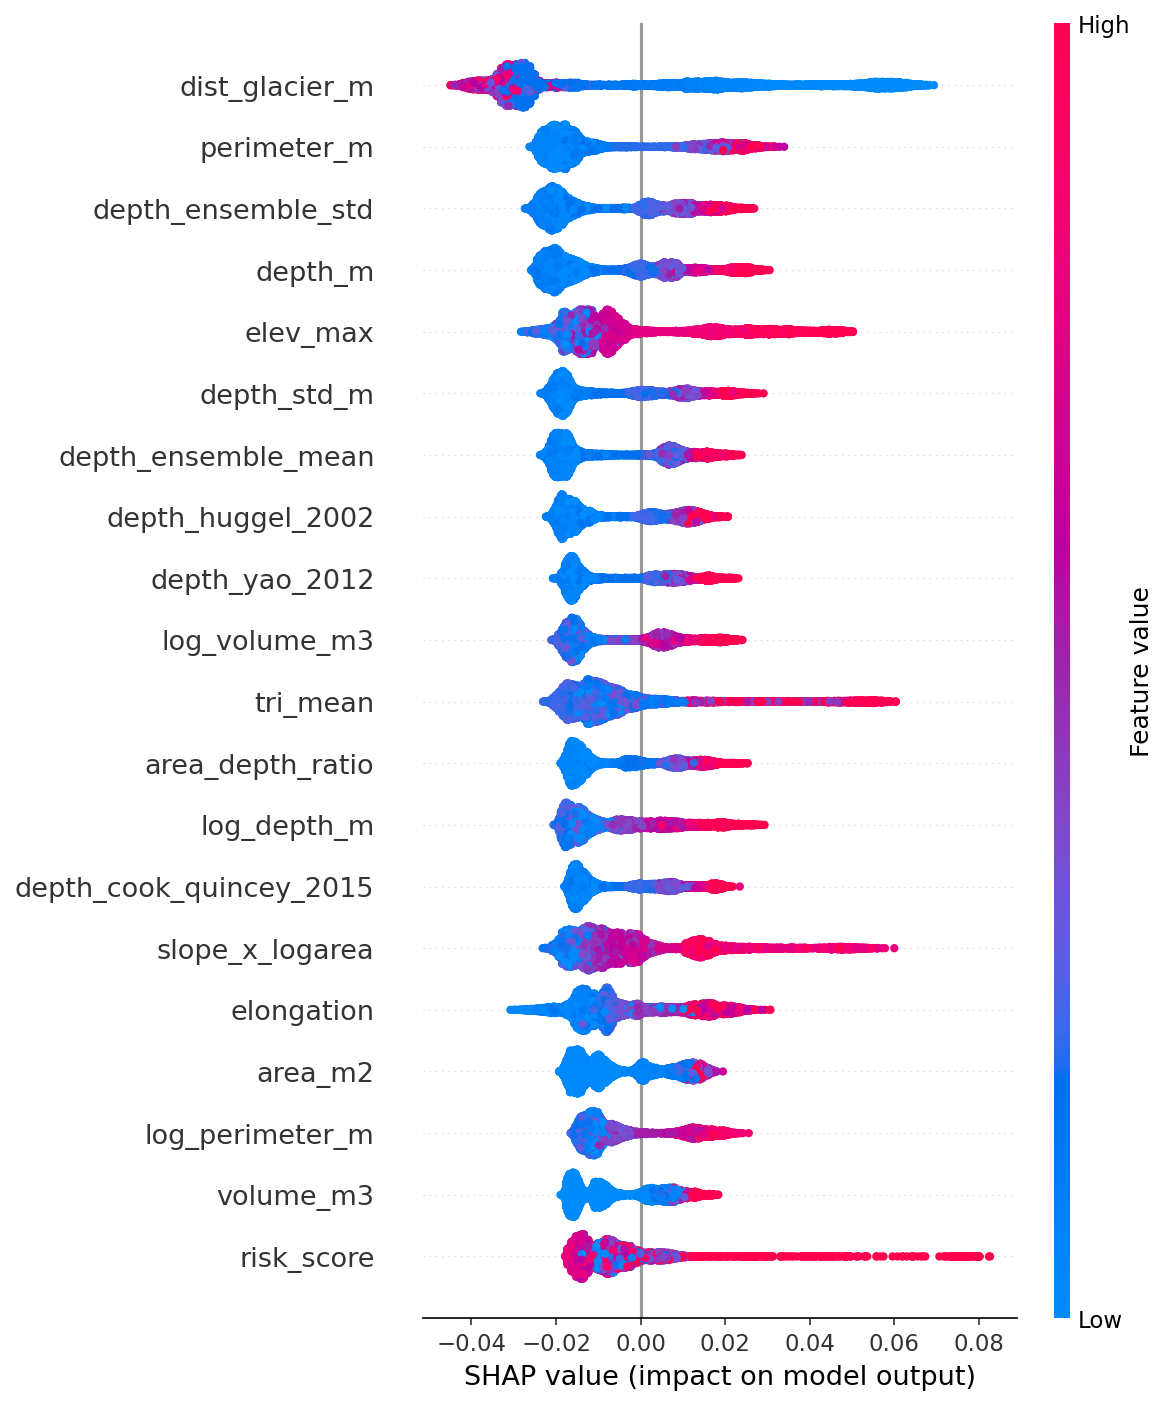

Saved: shap_beeswarm.png


In [8]:
# SHAP beeswarm / summary plot
if shap_values is not None and X is not None and SHAP_AVAILABLE:
    try:
        fig, ax = plt.subplots(figsize=(10, max(6, len(X.columns) * 0.4)))
        shap.summary_plot(
            shap_values,
            X,
            plot_type='dot',
            show=False,
            max_display=min(20, len(X.columns)),
        )
        plt.tight_layout()
        fig.savefig(FIG_DIR / 'shap_beeswarm.png', dpi=300, bbox_inches='tight')
        plt.show()
        print('Saved: shap_beeswarm.png')
    except Exception as e:
        print(f'WARNING: beeswarm plot failed: {e}')

        # Fallback: simple bar chart
        if importance_df is not None:
            fig, ax = plt.subplots(figsize=(9, 5))
            top_df = importance_df.head(15)
            ax.barh(top_df['feature'][::-1], top_df['mean_abs_shap'][::-1],
                    color='steelblue', alpha=0.8)
            ax.set_xlabel('Mean |SHAP value|')
            ax.set_title('SHAP Feature Importance (fallback bar chart)')
            ax.grid(alpha=0.3, axis='x')
            plt.tight_layout()
            fig.savefig(FIG_DIR / 'shap_beeswarm.png', dpi=300, bbox_inches='tight')
            plt.show()
            print('Saved fallback bar chart as shap_beeswarm.png')
else:
    print('SHAP values not available — skipping beeswarm plot.')

## 5. Feature Importance DataFrame and CSV

In [9]:
# Save SHAP feature importance to CSV
if importance_df is not None:
    out_path = PROCESSED_DIR / 'shap_feature_importance.csv'
    out_path.parent.mkdir(parents=True, exist_ok=True)
    importance_df.to_csv(out_path, index=False)
    print(f'Saved SHAP importance: {out_path}')
    print()
    print('Top 10 features:')
    print(importance_df.head(10).to_string(index=False))
else:
    print('importance_df not available — skipping CSV save.')

Saved SHAP importance: /home/andre/Documents/GLOF_Andes_Project-Paper/data/processed/shap_feature_importance.csv

Top 10 features:
            feature  mean_abs_shap
     dist_glacier_m       0.029925
        perimeter_m       0.018471
 depth_ensemble_std       0.016205
            depth_m       0.015505
           elev_max       0.015275
        depth_std_m       0.015030
depth_ensemble_mean       0.014934
  depth_huggel_2002       0.013524
     depth_yao_2012       0.013061
      log_volume_m3       0.012831


## 6. SHAP Dependence Plots (Top 6 Features)

Top 6 features: ['dist_glacier_m', 'perimeter_m', 'depth_ensemble_std', 'depth_m', 'elev_max', 'depth_std_m']


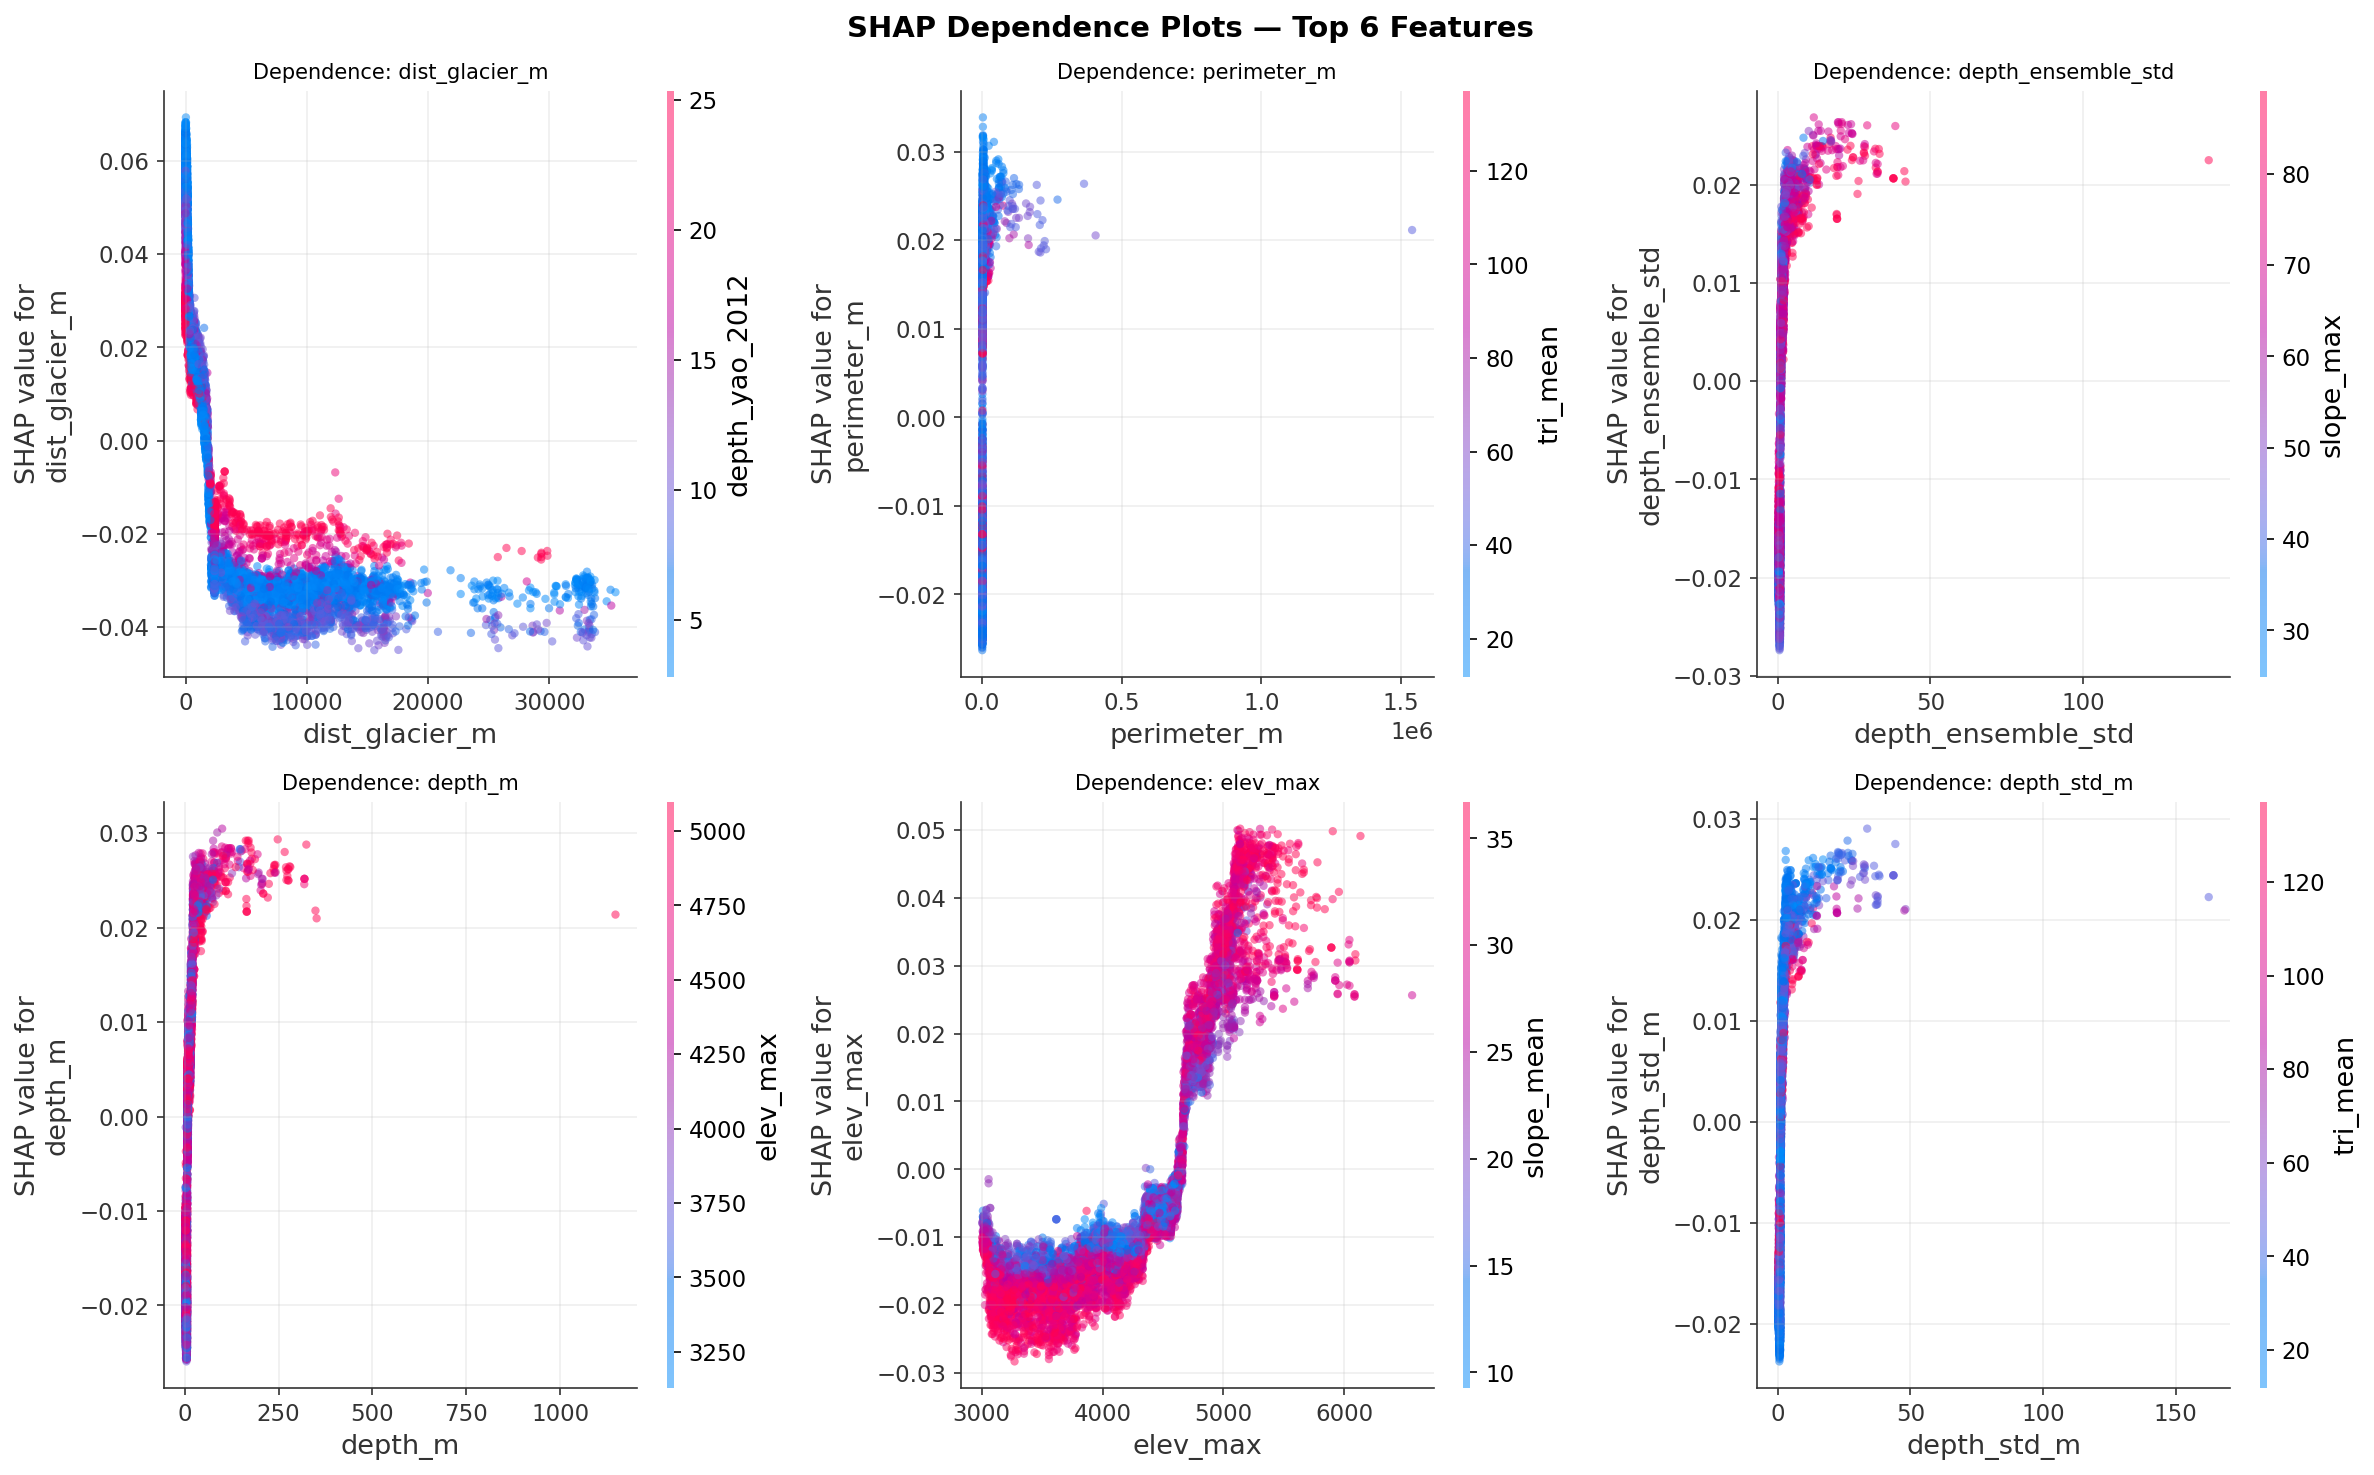

Saved: shap_dependence.png


In [10]:
# SHAP dependence plots for top 6 features — 2x3 grid
if shap_values is not None and X is not None and importance_df is not None and SHAP_AVAILABLE:
    top6 = importance_df['feature'].head(6).tolist()
    print(f'Top 6 features: {top6}')

    fig, axes = plt.subplots(2, 3, figsize=(16, 10))
    fig.suptitle('SHAP Dependence Plots — Top 6 Features', fontsize=14, fontweight='bold')
    axes_flat = axes.flatten()

    for i, feat in enumerate(top6):
        ax = axes_flat[i]
        try:
            shap.dependence_plot(
                feat,
                shap_values,
                X,
                ax=ax,
                show=False,
                alpha=0.5,
            )
            ax.set_title(f'Dependence: {feat}', fontsize=10)
            ax.grid(alpha=0.2)
        except Exception as e:
            # Fallback: manual scatter
            feat_vals = X[feat].values
            feat_shap = shap_values[:, list(X.columns).index(feat)]
            ax.scatter(feat_vals, feat_shap, alpha=0.4, s=10, color='steelblue')
            ax.axhline(0, color='black', lw=0.8, linestyle='--')
            ax.set_xlabel(feat)
            ax.set_ylabel('SHAP value')
            ax.set_title(f'{feat}\n(manual scatter)', fontsize=10)
            ax.grid(alpha=0.2)

    # Hide unused panels
    for j in range(len(top6), len(axes_flat)):
        axes_flat[j].set_visible(False)

    plt.tight_layout()
    fig.savefig(FIG_DIR / 'shap_dependence.png', dpi=300, bbox_inches='tight')
    plt.show()
    print('Saved: shap_dependence.png')
else:
    print('SHAP values not available — skipping dependence plots.')

## 7. Individual Explanation — Highest Risk Lake

Highest risk lake index: 54
Predicted probability  : 1.0000
True label             : 1



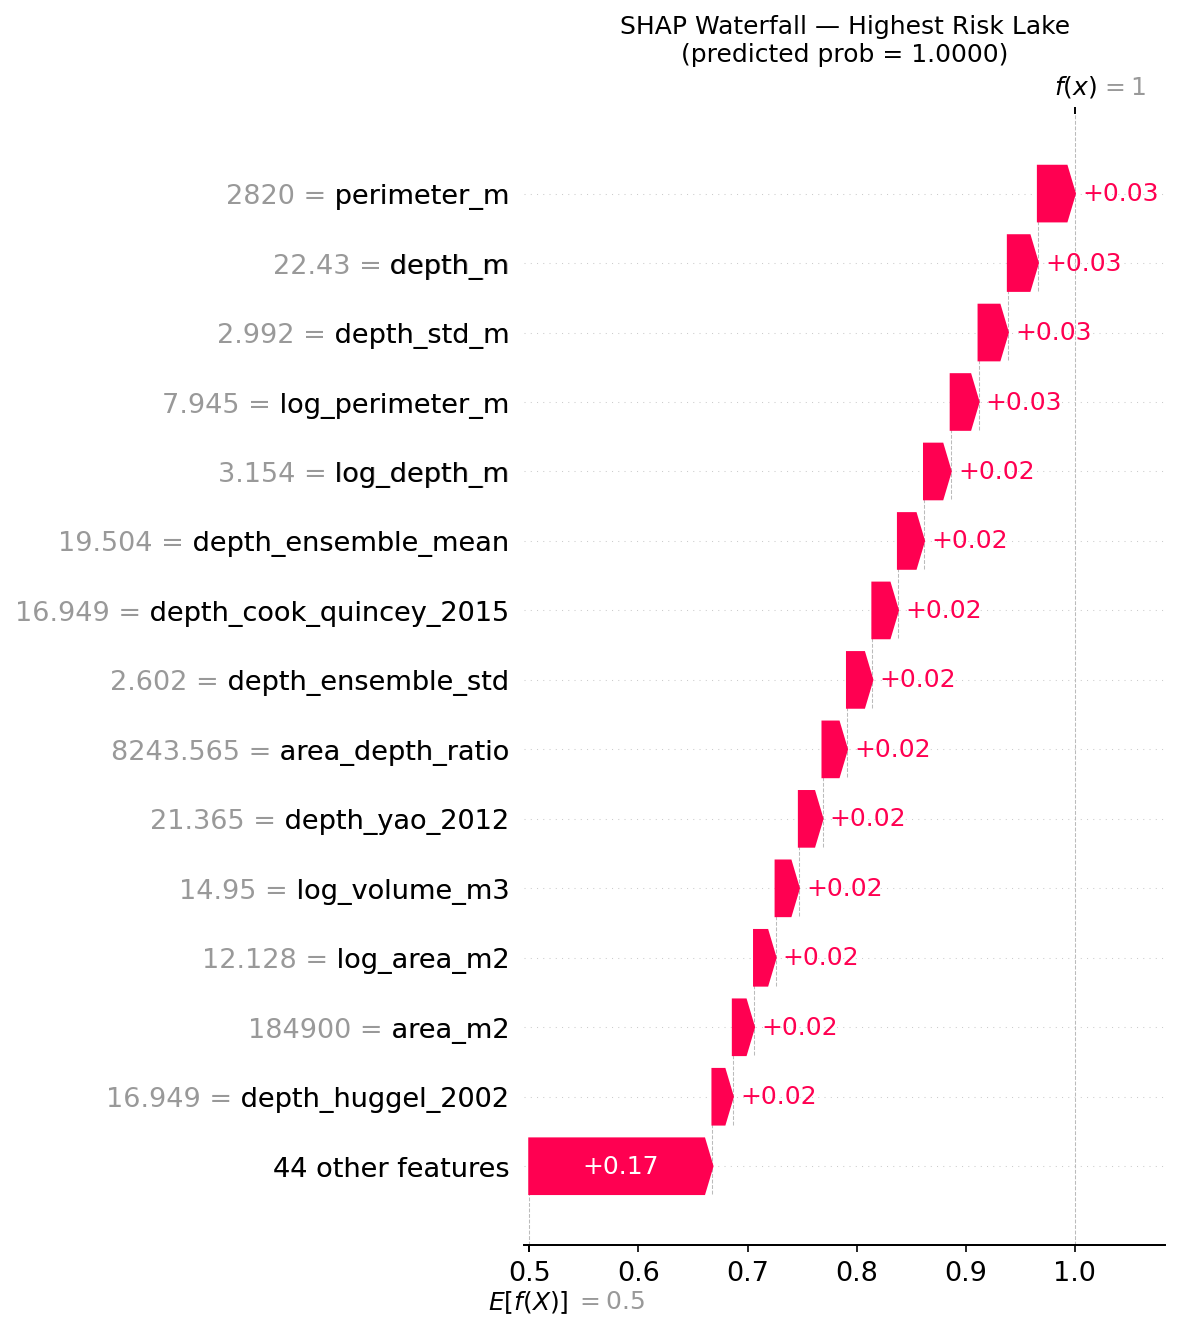

Saved: shap_waterfall_highrisk.png


In [11]:
# Waterfall plot for highest-risk lake
if shap_values is not None and X is not None and SHAP_AVAILABLE and model is not None:
    y_pred = model.predict_proba(X)[:, 1]
    high_risk_idx = int(np.argmax(y_pred))
    print(f'Highest risk lake index: {high_risk_idx}')
    print(f'Predicted probability  : {y_pred[high_risk_idx]:.4f}')
    print(f'True label             : {y[high_risk_idx] if y is not None else "unknown"}')
    print()

    try:
        exp_value = float(expected_value) if expected_value is not None else 0.5

        shap_explanation = shap.Explanation(
            values=shap_values[high_risk_idx],
            base_values=exp_value,
            data=X.iloc[high_risk_idx].values,
            feature_names=list(X.columns),
        )

        fig, ax = plt.subplots(figsize=(10, max(5, len(X.columns) * 0.35)))
        shap.waterfall_plot(shap_explanation, show=False, max_display=15)
        plt.title(f'SHAP Waterfall — Highest Risk Lake\n(predicted prob = {y_pred[high_risk_idx]:.4f})',
                  fontsize=12)
        plt.tight_layout()
        fig.savefig(FIG_DIR / 'shap_waterfall_highrisk.png', dpi=300, bbox_inches='tight')
        plt.show()
        print('Saved: shap_waterfall_highrisk.png')

    except Exception as e:
        print(f'WARNING: Waterfall plot failed: {e}')
        # Fallback: bar chart of SHAP values for this observation
        sv = shap_values[high_risk_idx]
        feat_names = list(X.columns)
        sorted_idx = np.argsort(np.abs(sv))[::-1][:15]
        fig, ax = plt.subplots(figsize=(9, 5))
        colors = ['crimson' if sv[i] > 0 else 'steelblue' for i in sorted_idx]
        ax.barh([feat_names[i] for i in sorted_idx[::-1]],
                [sv[i] for i in sorted_idx[::-1]],
                color=[colors[j] for j in range(len(sorted_idx) - 1, -1, -1)])
        ax.axvline(0, color='black', lw=0.8)
        ax.set_xlabel('SHAP value')
        ax.set_title(f'SHAP Values — Highest Risk Lake\n(p={y_pred[high_risk_idx]:.4f})')
        ax.grid(alpha=0.2, axis='x')
        plt.tight_layout()
        fig.savefig(FIG_DIR / 'shap_waterfall_highrisk.png', dpi=300, bbox_inches='tight')
        plt.show()
        print('Saved fallback bar chart as shap_waterfall_highrisk.png')
else:
    print('SHAP values or model not available — skipping waterfall plot.')

## 8. GLOF vs Non-GLOF Comparison

Top features with highest SHAP difference (GLOF - non-GLOF):
            feature  mean_shap_glof  mean_shap_noglof  difference
     dist_glacier_m        0.027626         -0.007537    0.035163
        perimeter_m        0.019364         -0.010479    0.029843
            depth_m        0.018126         -0.009114    0.027240
 depth_ensemble_std        0.016866         -0.009300    0.026166
        depth_std_m        0.018128         -0.007842    0.025970
        log_depth_m        0.016772         -0.007185    0.023957
depth_ensemble_mean        0.015754         -0.008038    0.023793
   area_depth_ratio        0.015464         -0.006672    0.022136
      log_volume_m3        0.015036         -0.006813    0.021850
         risk_score        0.015065         -0.006766    0.021831


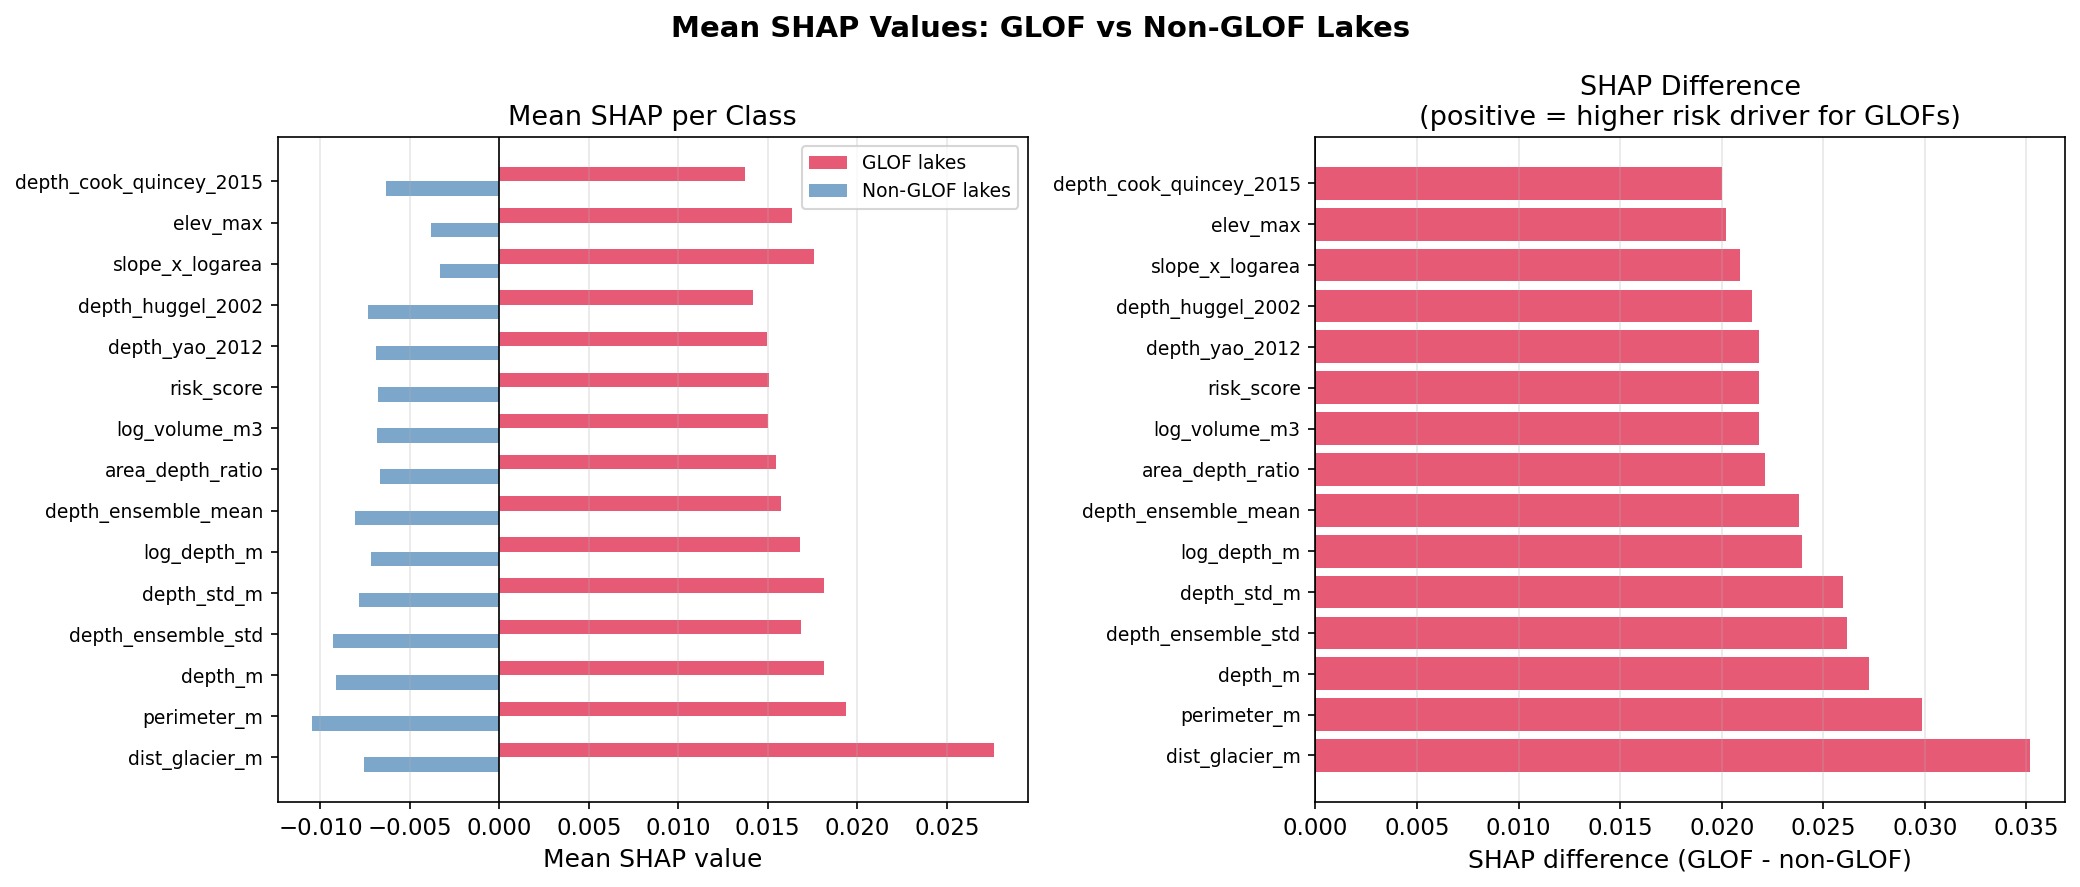

Saved: shap_comparison.png


In [12]:
# Compare mean SHAP values between GLOF and non-GLOF lakes
if shap_values is not None and y is not None and X is not None:
    glof_mask   = y == 1
    noglof_mask = y == 0

    mean_shap_glof   = shap_values[glof_mask].mean(axis=0)
    mean_shap_noglof = shap_values[noglof_mask].mean(axis=0)

    feat_names = list(X.columns)
    diff_df = pd.DataFrame({
        'feature': feat_names,
        'mean_shap_glof': mean_shap_glof,
        'mean_shap_noglof': mean_shap_noglof,
        'difference': mean_shap_glof - mean_shap_noglof,
    }).sort_values('difference', ascending=False).reset_index(drop=True)

    print('Top features with highest SHAP difference (GLOF - non-GLOF):')
    print(diff_df.head(10).to_string(index=False))

    top_n = min(15, len(diff_df))
    plot_df = diff_df.head(top_n)

    fig, axes = plt.subplots(1, 2, figsize=(14, max(5, top_n * 0.4)))
    fig.suptitle('Mean SHAP Values: GLOF vs Non-GLOF Lakes', fontsize=14, fontweight='bold')

    # Panel A: side-by-side bars
    ax = axes[0]
    y_pos = np.arange(top_n)
    bar_h = 0.35
    ax.barh(y_pos + bar_h / 2, plot_df['mean_shap_glof'],
            bar_h, label='GLOF lakes', color='crimson', alpha=0.7)
    ax.barh(y_pos - bar_h / 2, plot_df['mean_shap_noglof'],
            bar_h, label='Non-GLOF lakes', color='steelblue', alpha=0.7)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(plot_df['feature'], fontsize=9)
    ax.axvline(0, color='black', lw=0.8)
    ax.set_xlabel('Mean SHAP value')
    ax.set_title('Mean SHAP per Class')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3, axis='x')

    # Panel B: difference bars
    ax = axes[1]
    colors = ['crimson' if d > 0 else 'steelblue' for d in plot_df['difference']]
    ax.barh(y_pos, plot_df['difference'], color=colors, alpha=0.7)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(plot_df['feature'], fontsize=9)
    ax.axvline(0, color='black', lw=0.8)
    ax.set_xlabel('SHAP difference (GLOF - non-GLOF)')
    ax.set_title('SHAP Difference\n(positive = higher risk driver for GLOFs)')
    ax.grid(alpha=0.3, axis='x')

    plt.tight_layout()
    fig.savefig(FIG_DIR / 'shap_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()
    print('Saved: shap_comparison.png')
else:
    print('SHAP values or labels not available — skipping comparison plot.')

## 9. Validate H1/H2/H3 Thresholds with SHAP

Cross-check the threshold findings from Notebook 16 using SHAP values.

In [13]:
# Load threshold summary from Notebook 16
threshold_path = PROCESSED_DIR / 'threshold_summary.csv'
thresholds_df = None

if threshold_path.exists():
    thresholds_df = pd.read_csv(threshold_path)
    print('Loaded threshold summary:')
    print(thresholds_df.to_string(index=False))
else:
    print(f'WARNING: threshold_summary.csv not found at {threshold_path}')
    print('         Run notebook 16 first.')

Loaded threshold summary:
                Hypothesis                      Feature   Threshold  Risk_Below  Risk_Above Risk_Ratio  MWU_p_value  Bootstrap_p_value Confirmed
      H1: Area/Depth Ratio             area_depth_ratio 493457.1731      0.3295      0.8560        2.6          1.0              0.351        NO
   H2: Growth Rate vs Area growth_rate_m2_yr vs area_m2         NaN      0.6981     -0.1007 Spearman r          0.0                NaN        NO
H3: Critical Distance Zone                   slope_mean     44.4965      0.2579      0.4269        1.0          NaN                NaN        NO


H1 SHAP validation — area_depth_ratio:
  Spearman r (feature vs SHAP) = 0.671, p = 0.0000
  Positive correlation confirms higher values drive higher predictions


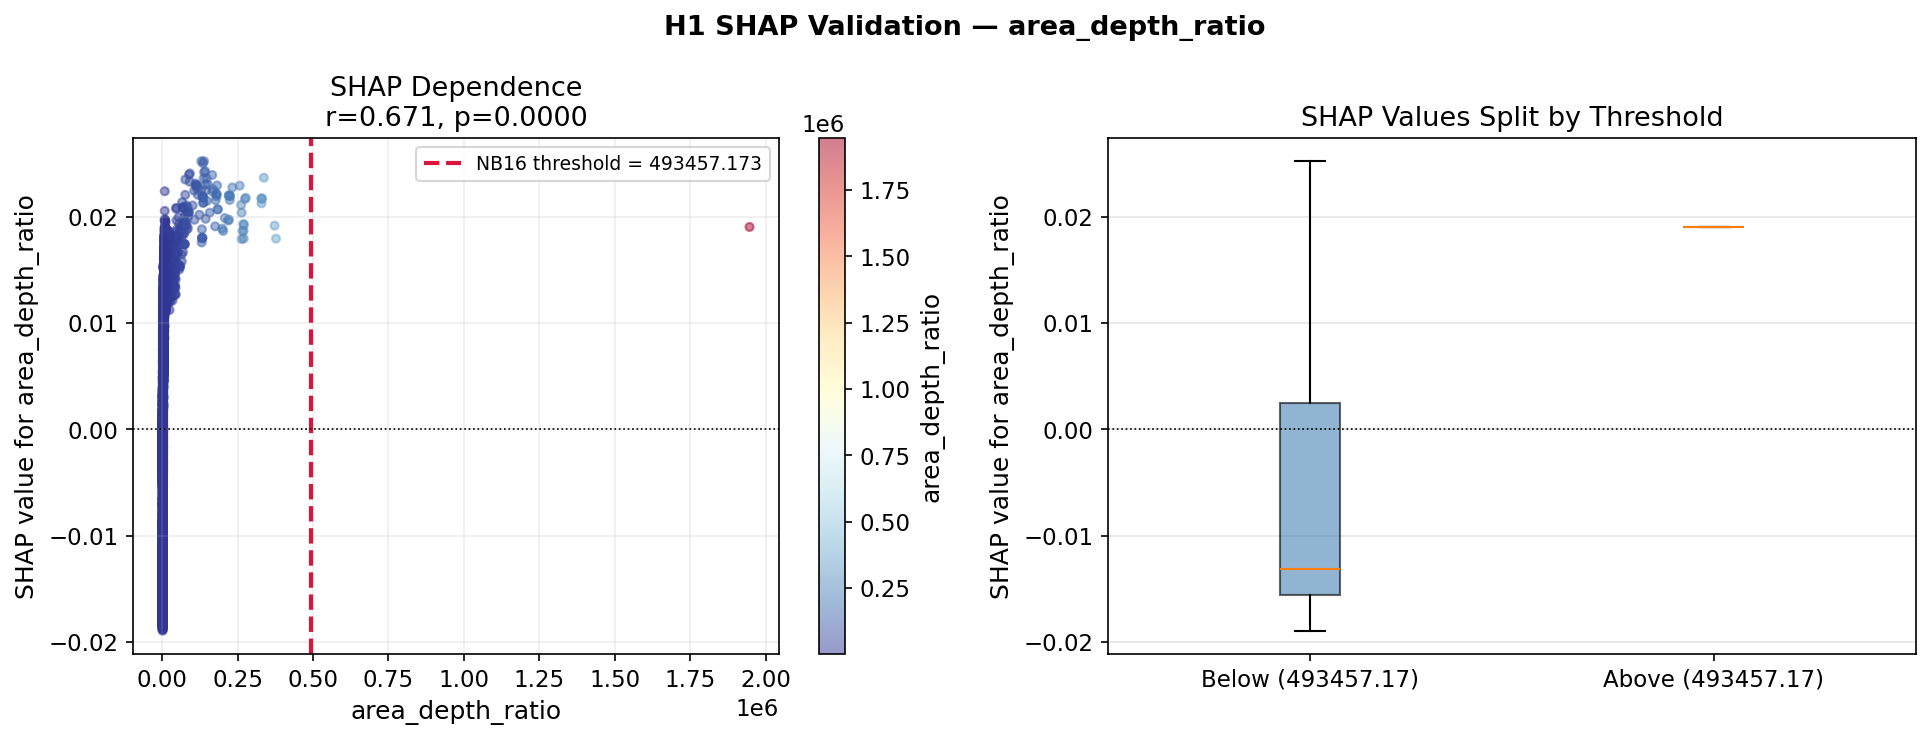

H1 SHAP validation complete.

H2 SHAP validation — growth_rate_m2_yr:
  Spearman r = 0.718, p = 0.0000
  Positive SHAP for high growth rates: True
  H2 SHAP consistent: True


In [14]:
# Validate H1 (area_depth_ratio) with SHAP dependence
if shap_values is not None and X is not None and SHAP_AVAILABLE:
    # Find area/depth-related feature
    adr_candidates = ['area_depth_ratio', 'area_m2', 'lake_area']
    adr_col = next((c for c in adr_candidates if c in X.columns), None)

    if adr_col:
        feat_idx = list(X.columns).index(adr_col)
        feat_shap = shap_values[:, feat_idx]
        feat_vals = X[adr_col].values

        # Correlation between feature values and SHAP values
        from scipy.stats import spearmanr
        r, p = spearmanr(feat_vals, feat_shap)
        print(f'H1 SHAP validation — {adr_col}:')
        print(f'  Spearman r (feature vs SHAP) = {r:.3f}, p = {p:.4f}')
        print(f'  Positive correlation confirms higher values drive higher predictions')

        # Get H1 threshold from summary if available
        h1_threshold = None
        if thresholds_df is not None:
            h1_row = thresholds_df[thresholds_df['Hypothesis'].str.contains('H1', na=False)]
            if len(h1_row) > 0:
                thresh_val = h1_row['Threshold'].values[0]
                try:
                    h1_threshold = float(thresh_val)
                except (ValueError, TypeError):
                    h1_threshold = None

        fig, axes = plt.subplots(1, 2, figsize=(13, 5))
        fig.suptitle(f'H1 SHAP Validation — {adr_col}', fontsize=13, fontweight='bold')

        # Panel A: dependence with threshold
        ax = axes[0]
        sc = ax.scatter(feat_vals, feat_shap,
                        c=feat_vals, cmap='RdYlBu_r', alpha=0.5, s=15)
        plt.colorbar(sc, ax=ax, label=adr_col)
        if h1_threshold is not None:
            ax.axvline(h1_threshold, color='crimson', lw=2, linestyle='--',
                       label=f'NB16 threshold = {h1_threshold:.3f}')
            ax.legend(fontsize=9)
        ax.axhline(0, color='black', lw=0.8, linestyle=':')
        ax.set_xlabel(adr_col)
        ax.set_ylabel(f'SHAP value for {adr_col}')
        ax.set_title(f'SHAP Dependence\nr={r:.3f}, p={p:.4f}')
        ax.grid(alpha=0.2)

        # Panel B: split by threshold
        ax = axes[1]
        if h1_threshold is not None:
            below = feat_shap[feat_vals < h1_threshold]
            above = feat_shap[feat_vals >= h1_threshold]
            bp = ax.boxplot([below, above],
                            labels=[f'Below ({h1_threshold:.2f})',
                                    f'Above ({h1_threshold:.2f})'],
                            patch_artist=True)
            bp['boxes'][0].set_facecolor('steelblue')
            bp['boxes'][0].set_alpha(0.6)
            bp['boxes'][1].set_facecolor('crimson')
            bp['boxes'][1].set_alpha(0.6)
            ax.axhline(0, color='black', lw=0.8, linestyle=':')
            ax.set_ylabel(f'SHAP value for {adr_col}')
            ax.set_title('SHAP Values Split by Threshold')
            ax.grid(alpha=0.3, axis='y')
        else:
            ax.text(0.5, 0.5, 'No threshold from NB16',
                    ha='center', va='center', transform=ax.transAxes, fontsize=12)
            ax.set_title('Threshold comparison (run NB16 first)')

        plt.tight_layout()
        plt.show()
        print('H1 SHAP validation complete.')
    else:
        print('WARNING: No area/depth ratio feature found for H1 SHAP validation.')

# Validate H2: verify positive SHAP for high growth rates
growth_candidates = ['growth_rate_m2_yr', 'area_change_rate', 'dA_dt']
growth_col = next((c for c in growth_candidates if X is not None and c in X.columns), None)

if shap_values is not None and X is not None and growth_col:
    feat_idx = list(X.columns).index(growth_col)
    feat_shap = shap_values[:, feat_idx]
    feat_vals = X[growth_col].values

    from scipy.stats import spearmanr
    r, p = spearmanr(feat_vals, feat_shap)
    print(f'\nH2 SHAP validation — {growth_col}:')
    print(f'  Spearman r = {r:.3f}, p = {p:.4f}')
    high_growth_positive = r > 0
    print(f'  Positive SHAP for high growth rates: {high_growth_positive}')
    print(f'  H2 SHAP consistent: {high_growth_positive}')
elif shap_values is not None and X is not None:
    print('\nH2 SHAP validation: No growth rate feature found.')

## 10. Combined Publication Figure (2x2 Grid)

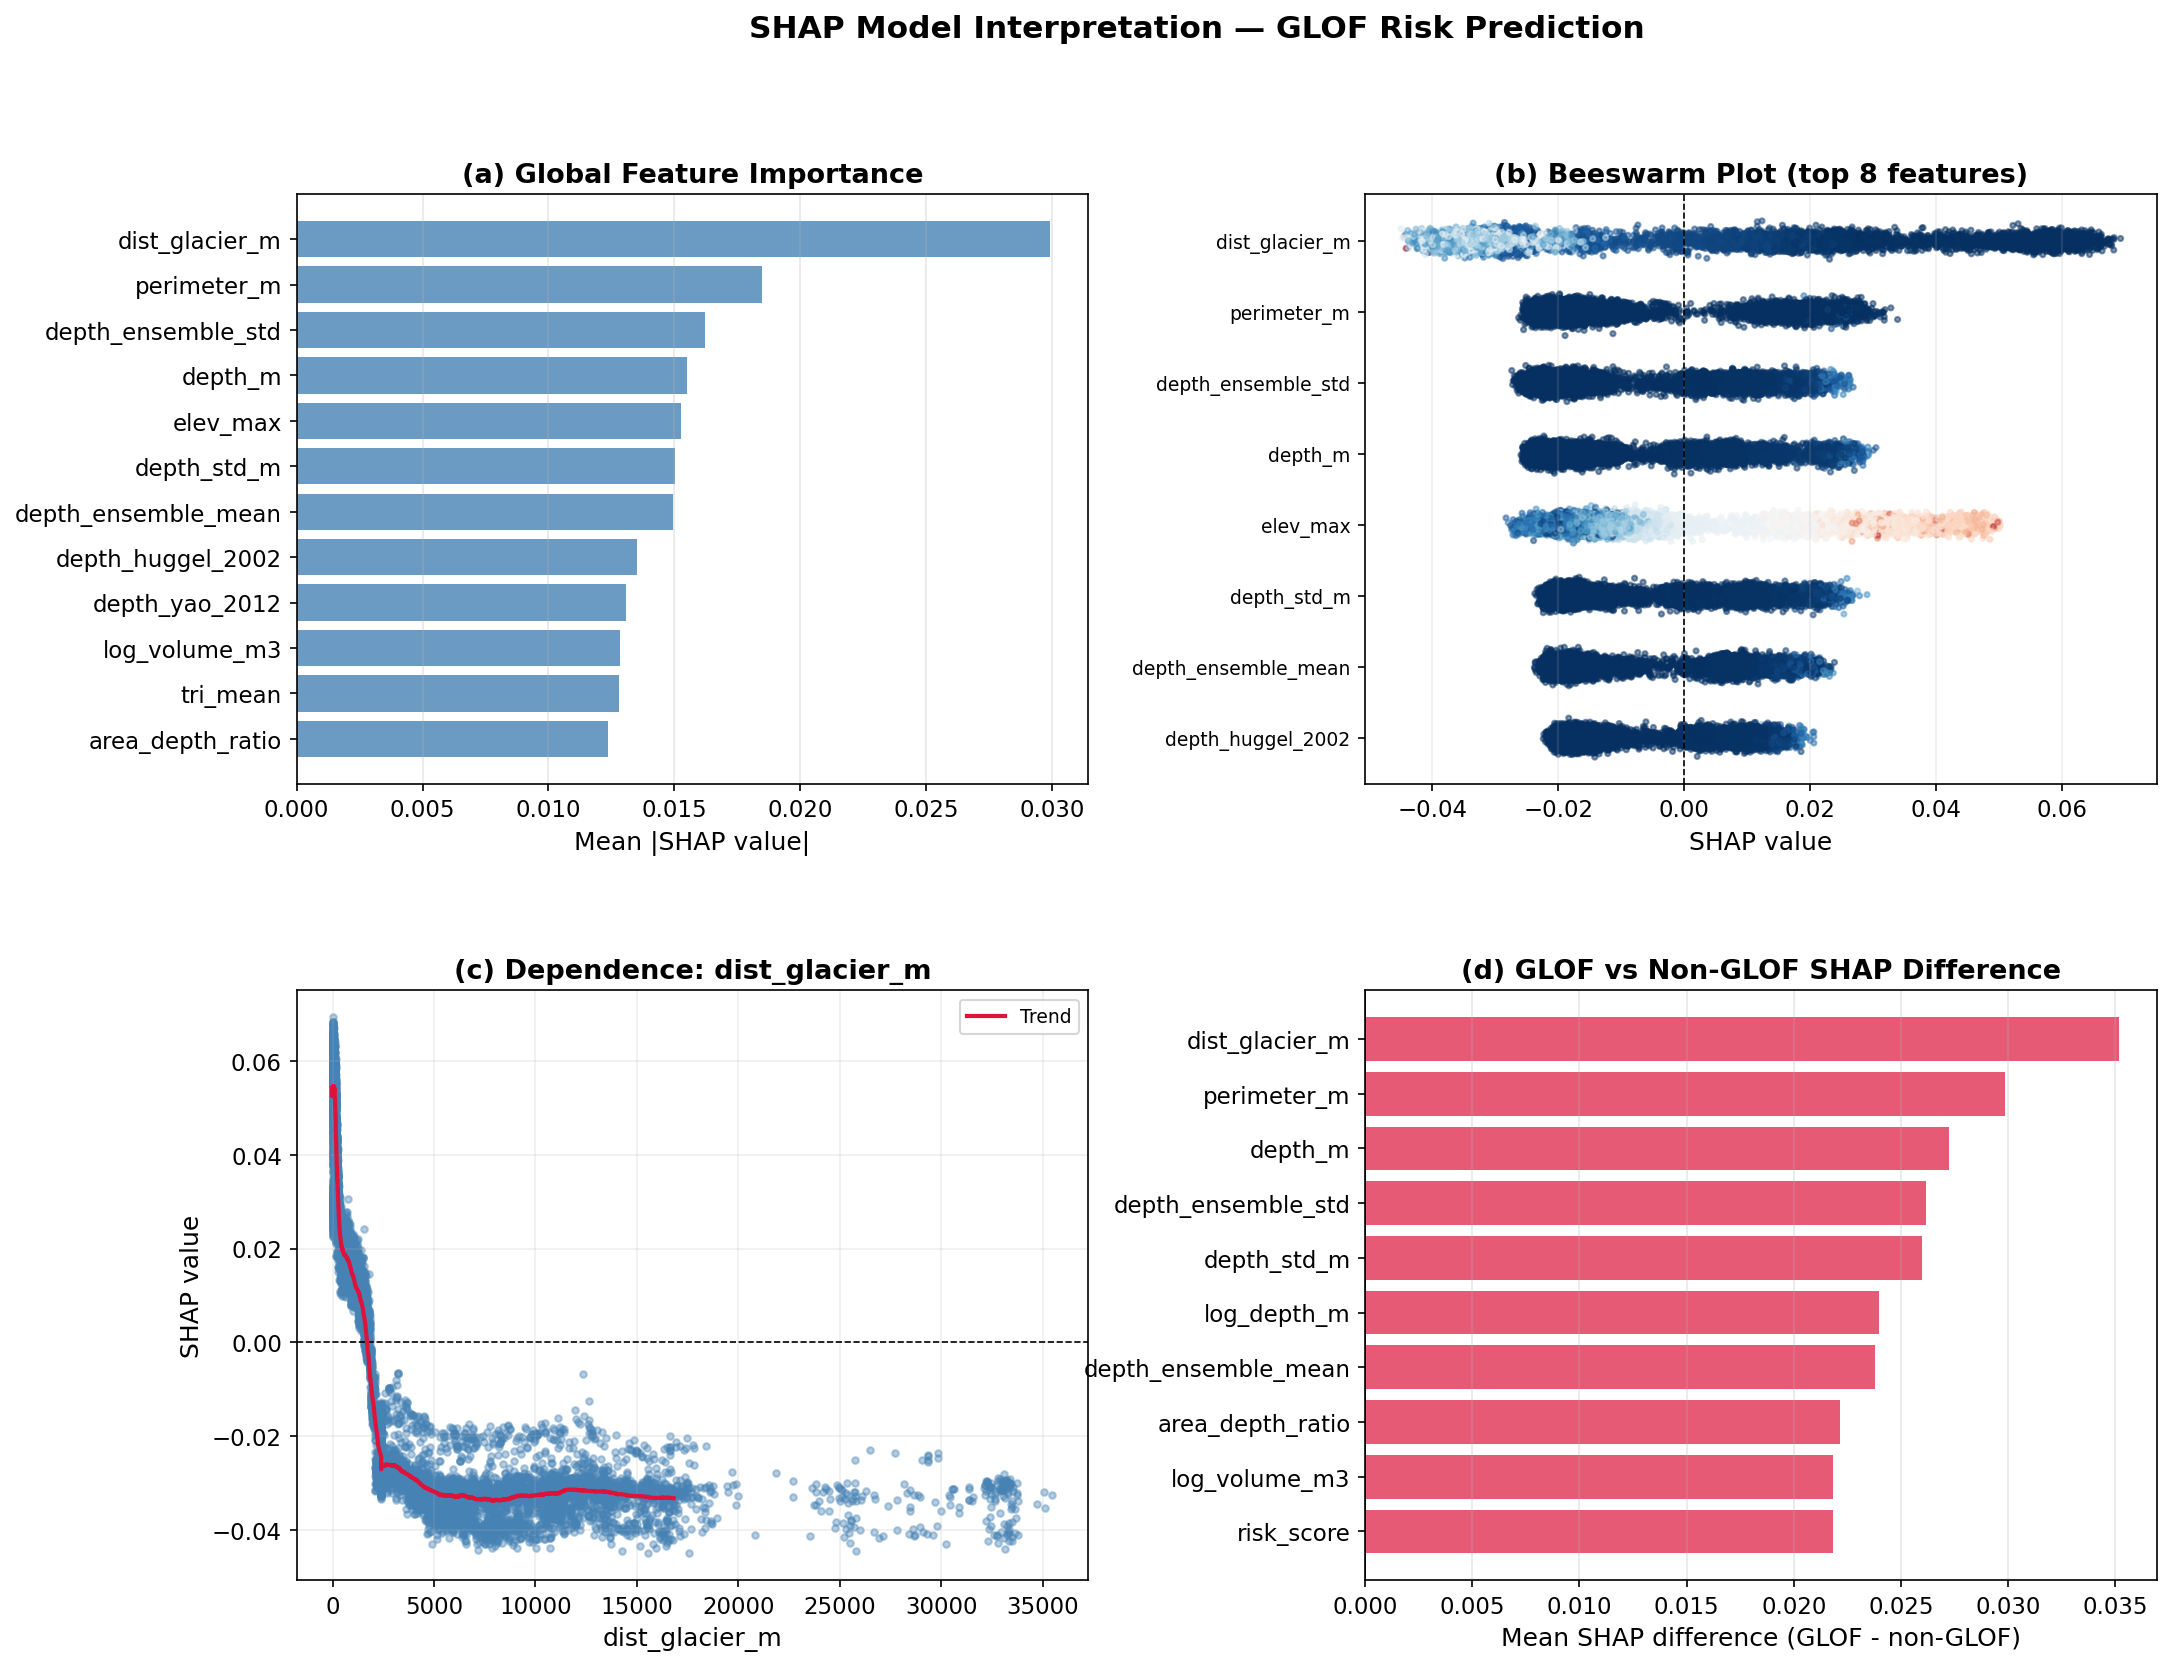

Saved: shap_publication_figure.png


In [15]:
# Combined 2x2 publication figure
if shap_values is not None and X is not None and importance_df is not None and SHAP_AVAILABLE:
    fig = plt.figure(figsize=(16, 12))
    gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.35, wspace=0.35)
    fig.suptitle('SHAP Model Interpretation — GLOF Risk Prediction',
                 fontsize=15, fontweight='bold', y=0.98)

    # ---- Panel A: Feature importance bar ----
    ax_a = fig.add_subplot(gs[0, 0])
    top_n = min(12, len(importance_df))
    top_df = importance_df.head(top_n)
    ax_a.barh(top_df['feature'][::-1], top_df['mean_abs_shap'][::-1],
              color='steelblue', alpha=0.8)
    ax_a.set_xlabel('Mean |SHAP value|')
    ax_a.set_title('(a) Global Feature Importance', fontweight='bold')
    ax_a.grid(alpha=0.3, axis='x')

    # ---- Panel B: Beeswarm (manual scatter) ----
    ax_b = fig.add_subplot(gs[0, 1])
    top_features_b = importance_df['feature'].head(8).tolist()
    for i, feat in enumerate(top_features_b[::-1]):
        feat_idx = list(X.columns).index(feat)
        sv = shap_values[:, feat_idx]
        fv = X[feat].values
        # Normalize feature values to [0,1] for color
        fv_norm = (fv - fv.min()) / (fv.max() - fv.min() + 1e-9)
        jitter = np.random.default_rng(i).normal(0, 0.07, size=len(sv))
        sc = ax_b.scatter(sv, np.full_like(sv, i) + jitter,
                          c=fv_norm, cmap='RdBu_r', s=6, alpha=0.5,
                          vmin=0, vmax=1)
    ax_b.set_yticks(range(len(top_features_b)))
    ax_b.set_yticklabels(top_features_b[::-1], fontsize=9)
    ax_b.axvline(0, color='black', lw=0.8, linestyle='--')
    ax_b.set_xlabel('SHAP value')
    ax_b.set_title('(b) Beeswarm Plot (top 8 features)', fontweight='bold')
    ax_b.grid(alpha=0.2, axis='x')

    # ---- Panel C: Dependence plot for top feature ----
    ax_c = fig.add_subplot(gs[1, 0])
    top_feat = importance_df['feature'].iloc[0]
    top_feat_idx = list(X.columns).index(top_feat)
    top_sv = shap_values[:, top_feat_idx]
    top_fv = X[top_feat].values
    ax_c.scatter(top_fv, top_sv, alpha=0.4, s=10, color='steelblue')
    ax_c.axhline(0, color='black', lw=0.8, linestyle='--')

    # Smooth trend line
    sort_idx = np.argsort(top_fv)
    window = max(5, len(top_fv) // 20)
    kernel = np.ones(window) / window
    if len(top_fv) > window:
        smooth = np.convolve(top_sv[sort_idx], kernel, mode='valid')
        smooth_x = top_fv[sort_idx][window // 2: window // 2 + len(smooth)]
        ax_c.plot(smooth_x, smooth, color='crimson', lw=2, label='Trend')
        ax_c.legend(fontsize=9)

    ax_c.set_xlabel(top_feat)
    ax_c.set_ylabel(f'SHAP value')
    ax_c.set_title(f'(c) Dependence: {top_feat}', fontweight='bold')
    ax_c.grid(alpha=0.2)

    # ---- Panel D: GLOF vs non-GLOF SHAP comparison ----
    ax_d = fig.add_subplot(gs[1, 1])
    if y is not None:
        glof_mask   = y == 1
        noglof_mask = y == 0
        mean_glof   = shap_values[glof_mask].mean(axis=0)
        mean_noglof = shap_values[noglof_mask].mean(axis=0)
        diff = mean_glof - mean_noglof
        feat_names = list(X.columns)

        n_top = min(10, len(feat_names))
        sort_by_diff = np.argsort(np.abs(diff))[::-1][:n_top]
        plot_feats = [feat_names[i] for i in sort_by_diff]
        plot_diff  = diff[sort_by_diff]

        colors = ['crimson' if d > 0 else 'steelblue' for d in plot_diff]
        ax_d.barh(plot_feats[::-1], plot_diff[::-1],
                  color=colors[::-1], alpha=0.7)
        ax_d.axvline(0, color='black', lw=0.8)
        ax_d.set_xlabel('Mean SHAP difference (GLOF - non-GLOF)')
        ax_d.set_title('(d) GLOF vs Non-GLOF SHAP Difference', fontweight='bold')
        ax_d.grid(alpha=0.3, axis='x')
    else:
        ax_d.text(0.5, 0.5, 'Labels (y) not available',
                  ha='center', va='center', transform=ax_d.transAxes)

    fig.savefig(FIG_DIR / 'shap_publication_figure.png', dpi=300, bbox_inches='tight')
    plt.show()
    print('Saved: shap_publication_figure.png')
else:
    print('SHAP values not available — skipping publication figure.')

## Summary

### Key Outputs
- `data/processed/shap_feature_importance.csv` — ranked feature importances
- `figures/shap_importance_bar.png` — global importance bar chart
- `figures/shap_beeswarm.png` — beeswarm summary plot
- `figures/shap_dependence.png` — dependence plots for top 6 features
- `figures/shap_waterfall_highrisk.png` — waterfall for highest-risk lake
- `figures/shap_comparison.png` — GLOF vs non-GLOF comparison
- `figures/shap_publication_figure.png` — combined 2x2 publication figure

### Next Steps
- **Notebook 18**: Use SHAP insights for final publication figures

In [16]:
# List all saved SHAP figures
print('Saved SHAP figures:')
for p in sorted(FIG_DIR.glob('shap_*.png')):
    size_kb = p.stat().st_size / 1024
    print(f'  {p.name}  ({size_kb:.1f} KB)')

shap_csv = PROCESSED_DIR / 'shap_feature_importance.csv'
if shap_csv.exists():
    size_kb = shap_csv.stat().st_size / 1024
    print(f'\n  {shap_csv.name}  ({size_kb:.1f} KB)')

Saved SHAP figures:
  shap_beeswarm.png  (656.9 KB)
  shap_comparison.png  (314.9 KB)
  shap_dependence.png  (1415.3 KB)
  shap_importance_bar.png  (223.2 KB)
  shap_publication_figure.png  (1323.2 KB)
  shap_waterfall_highrisk.png  (350.2 KB)

  shap_feature_importance.csv  (2.0 KB)
